In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense
)

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [11]:
vocab_size = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


In [12]:
def build_model(model_type):

    model = Sequential()

    model.add(
        Embedding(
            vocab_size,
            64,
            input_length=maxlen
        )
    )

    if model_type == "RNN":
        model.add(SimpleRNN(64))

    elif model_type == "LSTM":
        model.add(LSTM(64))

    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [13]:
print("\nTraining RNN...\n")

rnn_model = build_model("RNN")

rnn_history = rnn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, y_test)
)



Training RNN...

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.6368 - loss: 0.6576 - val_accuracy: 0.6888 - val_loss: 0.6080
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7580 - loss: 0.5091 - val_accuracy: 0.7140 - val_loss: 0.5490
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8390 - loss: 0.3705 - val_accuracy: 0.8041 - val_loss: 0.4483


In [14]:
print("\nTraining LSTM...\n")

lstm_model = build_model("LSTM")

lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, y_test)
)



Training LSTM...

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7505 - loss: 0.4943 - val_accuracy: 0.8391 - val_loss: 0.3718
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8934 - loss: 0.2688 - val_accuracy: 0.8700 - val_loss: 0.3128
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9193 - loss: 0.2102 - val_accuracy: 0.8376 - val_loss: 0.4357


In [15]:
print("\nTraining GRU...\n")

gru_model = build_model("GRU")

gru_history = gru_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, y_test)
)



Training GRU...

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7669 - loss: 0.4576 - val_accuracy: 0.8482 - val_loss: 0.3501
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9010 - loss: 0.2498 - val_accuracy: 0.8669 - val_loss: 0.3291
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9272 - loss: 0.1926 - val_accuracy: 0.8642 - val_loss: 0.3452


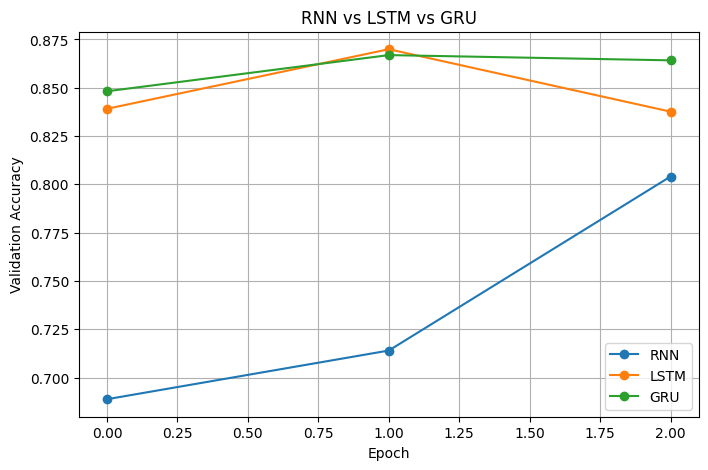

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    rnn_history.history['val_accuracy'],
    marker='o',
    label='RNN'
)

plt.plot(
    lstm_history.history['val_accuracy'],
    marker='o',
    label='LSTM'
)

plt.plot(
    gru_history.history['val_accuracy'],
    marker='o',
    label='GRU'
)

plt.title("RNN vs LSTM vs GRU")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()


In [17]:
rnn_acc = max(rnn_history.history['val_accuracy'])
lstm_acc = max(lstm_history.history['val_accuracy'])
gru_acc = max(gru_history.history['val_accuracy'])

print("\nFinal Validation Accuracy")

print(f"RNN  Accuracy : {rnn_acc:.4f}")
print(f"LSTM Accuracy : {lstm_acc:.4f}")
print(f"GRU  Accuracy : {gru_acc:.4f}")



Final Validation Accuracy
RNN  Accuracy : 0.8041
LSTM Accuracy : 0.8700
GRU  Accuracy : 0.8669


In [18]:
best_accuracy = max(rnn_acc, lstm_acc, gru_acc)

if best_accuracy == lstm_acc:
    best_model = "LSTM"

elif best_accuracy == gru_acc:
    best_model = "GRU"

else:
    best_model = "RNN"

print(f"\nBest Performing Model: {best_model}")


Best Performing Model: LSTM
